# 04 — Spectral Indices and LST Correlation

**Author:** Sharon Christa
**Date:** April 2026  
**Purpose:** Test the project's core hypothesis — **"higher concrete density ↔ higher surface temperature"** — by correlating spectral indices (NDVI, NDBI, NDWI) with Land Surface Temperature (LST) at the pixel level.

Notebooks 01 and 02/03 established two things side-by-side:
- LULC is changing (Dar densifying, Singapore greening) [notebook 01]
- LST varies spatially and over time [notebooks 02, 03]

Using tens of thousands of pixel samples, we compute the correlation coefficient between each pixel's temperature and its greenness/built-up/water indices. A **strong negative NDVI-LST correlation and strong positive NDBI-LST correlation** is the quantitative validation of our hypothesis.

### Literature benchmarks (what to expect)

Recent GEE-based UHI studies report:

| Study (city) | NDVI-LST R² | NDBI-LST R² |
|---|---|---|
| Nashik, India (2019) | −0.57 | +0.71 |
| Delhi-NCR (2005-2020) | −0.54 | +0.59 |
| Damascus, Syria (2022-23) | −0.46 to −0.79 | +0.40 to +0.70 |
| Da Nang, Vietnam (2024) | −0.52 | +0.57 |

If our results fall in these ranges, we've reproduced a well-established global pattern for two new cities.

### Method

- **Sentinel-2 Surface Reflectance** (10-30m) → compute NDVI, NDBI, NDWI
- **Landsat 8/9 thermal band** (30m, resampled) → LST via single-channel algorithm
- **Resample NDVI/NDBI/NDWI to match Landsat LST** grid (30m)
- **Stack all four bands** → sample ~10,000 random pixels per city
- **Pearson correlation** + linear regression + scatter plots

### Why Landsat LST (not MODIS)?

For this notebook only — MODIS's 1km resolution is too coarse to correlate meaningfully with 10m Sentinel-2 indices. Landsat 8/9 thermal at 30m is the sweet spot. Notebooks 02 and 03 use MODIS for city-wide trends (better temporal coverage); notebook 04 uses Landsat for spatial correlation (better resolution match).

## 1. Setup

In [1]:
import ee
import geemap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import pearsonr, linregress

In [2]:
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11

try:
    import sys
    sys.path.append('..')
    from src.gee_helpers import init_ee
    init_ee()
except Exception:
    try:
        ee.Initialize(project='black-octagon-291810')
        print('EE initialised')
    except Exception:
        ee.Authenticate()
        ee.Initialize(project='black-octagon-291810')

Earth Engine initialized with project: black-octagon-291810


## 2. Areas of Interest (same as notebooks 01-03)

In [3]:
aoi_dar = (ee.FeatureCollection("projects/sat-io/open-datasets/FAO/GAUL/GAUL_2024_L1")
           .filter(ee.Filter.eq("gaul1_name", "Dar Es Salaam")))
dar_geom = aoi_dar.geometry()

aoi_sgp = (ee.FeatureCollection("projects/sat-io/open-datasets/FAO/GAUL/GAUL_2024_L0")
           .filter(ee.Filter.eq("gaul0_name", "Singapore")))
sgp_geom = aoi_sgp.geometry()

geoms = {'Dar es Salaam': dar_geom, 'Singapore': sgp_geom}

## 3. Compute spectral indices from Sentinel-2

**Definitions:**
- **NDVI** = (NIR − RED) / (NIR + RED) → range [−1, 1]; higher = more vegetation
- **NDBI** = (SWIR − NIR) / (SWIR + NIR) → range [−1, 1]; higher = more built-up / impervious
- **NDWI** = (GREEN − NIR) / (GREEN + NIR) → range [−1, 1]; higher = more water/moisture

Sentinel-2 bands used: B3 (green), B4 (red), B8 (NIR), B11 (SWIR).

We use 2024 imagery as the reference year (most recent full year with complete Sentinel-2 + Landsat coverage). Using a single year avoids conflating correlation structure with time.

In [4]:
YEAR = 2024


def get_s2_indices(geom, year):
    """Return median Sentinel-2 composite with NDVI, NDBI, NDWI bands added."""
    start = f'{year}-01-01'
    end   = f'{year}-12-31'
    s2 = (ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
            .filterBounds(geom)
            .filterDate(start, end)
            .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20)))

    composite = s2.median().clip(geom)
    ndvi = composite.normalizedDifference(['B8',  'B4' ]).rename('NDVI')
    ndbi = composite.normalizedDifference(['B11', 'B8' ]).rename('NDBI')
    ndwi = composite.normalizedDifference(['B3',  'B8' ]).rename('NDWI')
    return composite.addBands([ndvi, ndbi, ndwi])


indices_dar = get_s2_indices(dar_geom, YEAR)
indices_sgp = get_s2_indices(sgp_geom, YEAR)

print(f"Sentinel-2 indices computed for {YEAR}")
print(f"  bands: {indices_dar.bandNames().getInfo()[-3:]}")

Sentinel-2 indices computed for 2024
  bands: ['NDVI', 'NDBI', 'NDWI']


## 4. Compute LST from Landsat 8/9

Landsat 8/9 Collection 2 Level 2 provides calibrated surface temperature directly in band `ST_B10`, with a scale factor of 0.00341802 and offset of 149.0 (result in Kelvin). We convert to Celsius and take an annual median.

The Landsat native resolution for the thermal band is 100m but the product is resampled to 30m for convenience.

In [5]:
def get_landsat_lst(geom, year):
    """Median Landsat 8/9 LST (°C) for a given year."""
    start = f'{year}-01-01'
    end   = f'{year}-12-31'

    def scale_lst(image):
        lst = (image.select('ST_B10')
                    .multiply(0.00341802)
                    .add(149.0)
                    .subtract(273.15)
                    .rename('LST'))
        return lst.copyProperties(image, ['system:time_start'])

    l8 = (ee.ImageCollection("LANDSAT/LC08/C02/T1_L2")
            .filterBounds(geom).filterDate(start, end)
            .filter(ee.Filter.lt('CLOUD_COVER', 20)))
    l9 = (ee.ImageCollection("LANDSAT/LC09/C02/T1_L2")
            .filterBounds(geom).filterDate(start, end)
            .filter(ee.Filter.lt('CLOUD_COVER', 20)))

    merged = l8.merge(l9).map(scale_lst)
    return merged.median().clip(geom).rename('LST')


lst_dar = get_landsat_lst(dar_geom, YEAR)
lst_sgp = get_landsat_lst(sgp_geom, YEAR)

# Sanity check — mean city LST
for name, img, geom in [('Dar', lst_dar, dar_geom), ('SGP', lst_sgp, sgp_geom)]:
    mean = img.reduceRegion(ee.Reducer.mean(), geom, 100, maxPixels=1e9).get('LST').getInfo()
    print(f"{name} mean Landsat LST {YEAR}: {mean:.2f}°C")

Dar mean Landsat LST 2024: 33.29°C
SGP mean Landsat LST 2024: 38.75°C


## 5. Stack bands and sample random pixels

We build a combined image: `[NDVI, NDBI, NDWI, LST]`, then use `ee.Image.sample()` to extract ~10,000 random pixel values per city. This avoids the full-raster correlation (which is slow and memory-heavy over large AOIs) while still giving statistically meaningful results.

The sample is returned as a pandas DataFrame for local stats and plotting.

In [7]:
N_SAMPLES = 10_000   # pixels per city
SCALE = 30           # matches Landsat thermal resolution


def stack_and_sample(indices_img, lst_img, geom, n=N_SAMPLES, scale=SCALE, seed=42):
    """Sample random pixels and return as pandas DataFrame."""
    stack = (indices_img.select(['NDVI', 'NDBI', 'NDWI'])
                        .addBands(lst_img.select('LST')))
    samples = stack.sample(
        region=geom,
        scale=scale,
        numPixels=n,
        seed=seed,
        geometries=False,
        dropNulls=True,
    )
    return geemap.ee_to_df(samples)


print("Sampling Dar es Salaam...")
df_dar = stack_and_sample(indices_dar, lst_dar, dar_geom)
df_dar['city'] = 'Dar es Salaam'

print("Sampling Singapore...")
df_sgp = stack_and_sample(indices_sgp, lst_sgp, sgp_geom)
df_sgp['city'] = 'Singapore'

df = pd.concat([df_dar, df_sgp], ignore_index=True)
print(f"\nTotal samples: {len(df):,}")
print(df.groupby('city').size())
df.head()

Sampling Dar es Salaam...
Sampling Singapore...

Total samples: 14,494
city
Dar es Salaam    5475
Singapore        9019
dtype: int64


,LST,NDBI,NDVI,NDWI,city
0,34.145342,0.086404,0.410166,-0.398902,Dar es Salaam
1,35.410010,-0.091245,0.685337,-0.580991,Dar es Salaam
2,30.693142,-0.095031,0.659729,-0.597456,Dar es Salaam
3,33.386542,0.004021,0.531376,-0.555416,Dar es Salaam
4,38.650293,0.103411,0.121951,-0.154409,Dar es Salaam


## 6. Pearson correlation: NDVI / NDBI / NDWI vs LST

For each city, compute the Pearson correlation coefficient (r) and R² between each index and LST. Sign and magnitude matter:

- **NDVI vs LST**: expect *negative* (more green → cooler)
- **NDBI vs LST**: expect *positive* (more built → hotter)
- **NDWI vs LST**: expect *negative* (more water → cooler)

In [8]:
def corr_summary(df_sub):
    rows = []
    for idx in ['NDVI', 'NDBI', 'NDWI']:
        r, p = pearsonr(df_sub[idx], df_sub['LST'])
        reg = linregress(df_sub[idx], df_sub['LST'])
        rows.append({
            'index': idx,
            'r':         r,
            'r_squared': r ** 2,
            'p_value':   p,
            'slope':     reg.slope,
            'intercept': reg.intercept,
        })
    return pd.DataFrame(rows)


corr_tables = {}
for city in ['Dar es Salaam', 'Singapore']:
    sub = df[df.city == city]
    tab = corr_summary(sub)
    corr_tables[city] = tab
    print(f"\n=== {city} (n={len(sub):,}) ===")
    print(tab.to_string(index=False))


=== Dar es Salaam (n=5,475) ===
index         r  r_squared       p_value     slope  intercept
 NDVI -0.364437   0.132814 1.302701e-171 -6.477946  36.489876
 NDBI  0.303510   0.092118 4.980582e-117  8.325899  33.614602
 NDWI  0.316525   0.100188 1.169140e-127  6.727324  36.593689

=== Singapore (n=9,019) ===
index         r  r_squared       p_value     slope  intercept
 NDVI -0.287774   0.082814 1.598695e-171 -4.264091  40.285523
 NDBI  0.575299   0.330969  0.000000e+00 15.159935  39.594923
 NDWI  0.123906   0.015353  3.420328e-32  1.938249  39.370119


## 7. Scatter plots — the visual proof

Six panels: 2 cities × 3 indices. Each panel shows the relationship between one index and LST. The regression line + R² in the corner is the money shot for your poster.

A strong linear trend here is direct visual evidence for the "concrete → heat" hypothesis.

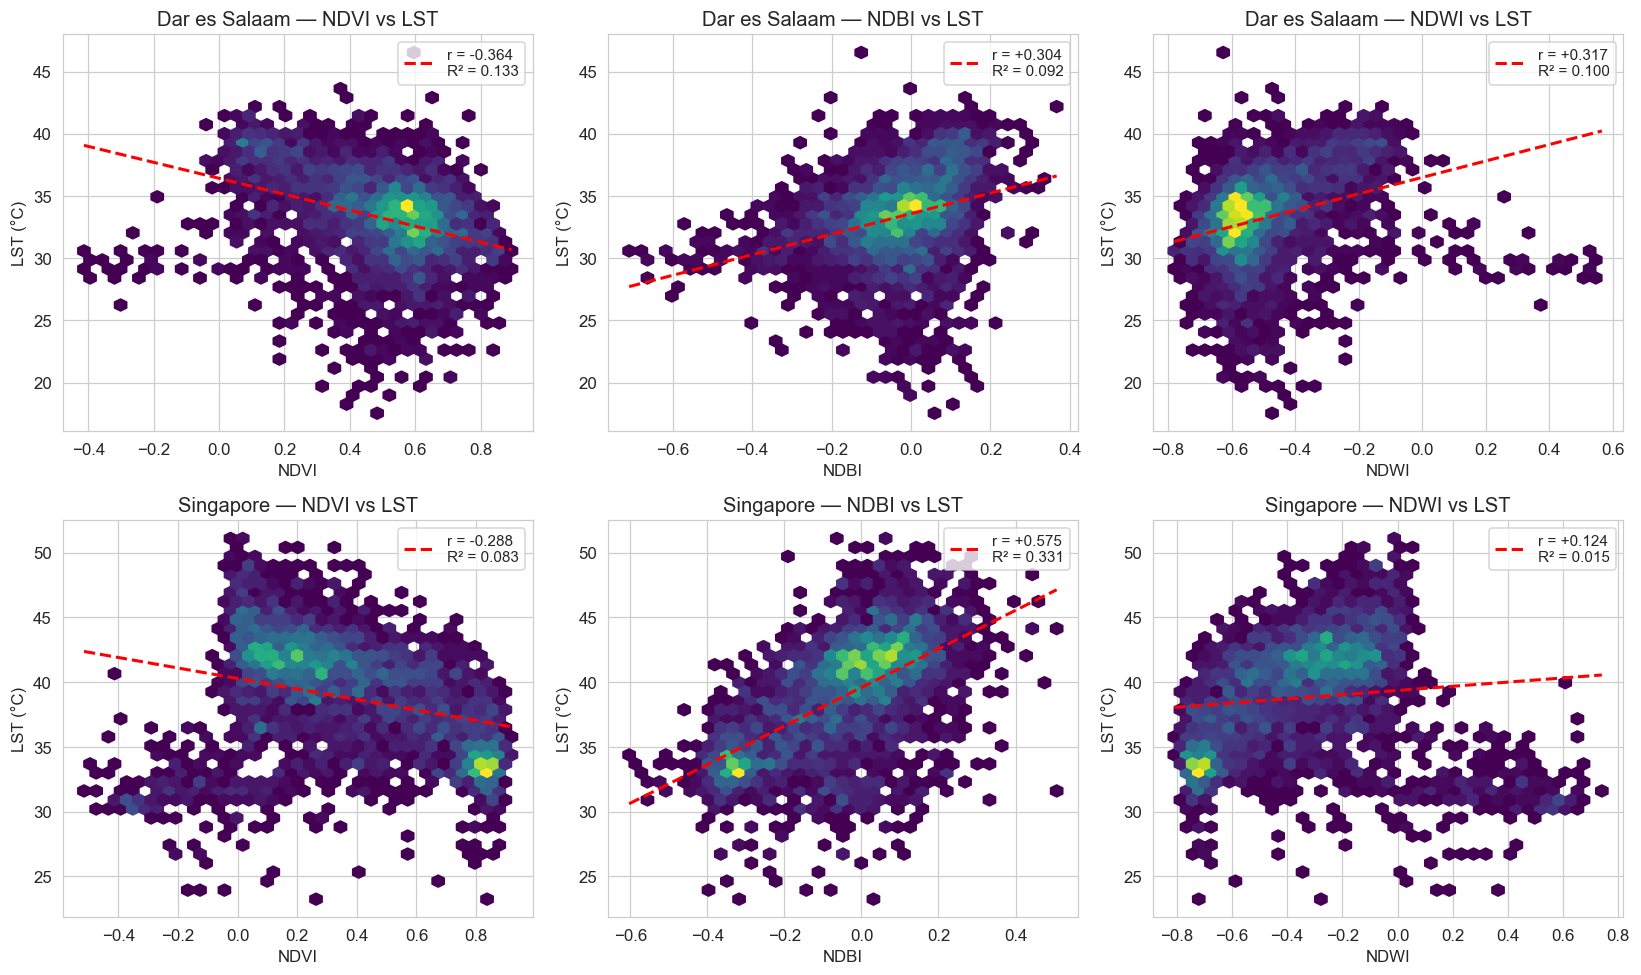

Saved: D:\uhi-dar-singapore\outputs\figures\04_indices_vs_lst.png


In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for row, city in enumerate(['Dar es Salaam', 'Singapore']):
    sub = df[df.city == city].sample(min(3000, len(df[df.city == city])), random_state=0)
    for col, idx in enumerate(['NDVI', 'NDBI', 'NDWI']):
        ax = axes[row, col]
        r, _ = pearsonr(df[df.city == city][idx], df[df.city == city]['LST'])

        # Hexbin density plot for speed + clarity with thousands of points
        hb = ax.hexbin(sub[idx], sub['LST'], gridsize=35, cmap='viridis', mincnt=1)

        # Linear regression overlay
        reg = linregress(sub[idx], sub['LST'])
        x = np.linspace(sub[idx].min(), sub[idx].max(), 50)
        ax.plot(x, reg.intercept + reg.slope * x, color='red', lw=2, ls='--',
                label=f'r = {r:+.3f}\nR² = {r**2:.3f}')

        ax.set_xlabel(idx)
        ax.set_ylabel('LST (°C)')
        ax.set_title(f'{city} — {idx} vs LST')
        ax.legend(loc='best', fontsize=10, frameon=True)

plt.tight_layout()
out_dir = Path('../outputs/figures')
out_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(out_dir / '04_indices_vs_lst.png', dpi=200, bbox_inches='tight')
plt.show()
print(f"Saved: {(out_dir / '04_indices_vs_lst.png').resolve()}")

## 8. LST stratified by land-cover class

Bonus analysis: using Dynamic World's class labels (from notebook 01's pipeline), compute mean LST for each of the 9 classes in each city. This is the **direct equivalent of Siswanto et al.'s Fig. 11** (the most-cited plot from your reference paper).

Expected pattern: `built > bare > crops > grass > shrub > trees > water`.

In [10]:
CLASS_LABELS = ['water','trees','grass','flooded_vegetation','crops',
                'shrub_and_scrub','built','bare','snow_and_ice']


def get_dw_label(geom, year):
    col = (ee.ImageCollection("GOOGLE/DYNAMICWORLD/V1")
             .filterBounds(geom)
             .filterDate(f'{year}-01-01', f'{year}-12-31')
             .select('label'))
    return col.reduce(ee.Reducer.mode()).rename('dw_class').clip(geom)


def lst_by_class(lst_img, dw_img, geom, scale=30):
    stack = lst_img.select('LST').addBands(dw_img.select('dw_class'))
    # Group reducer: mean LST grouped by dw_class
    result = stack.reduceRegion(
        reducer=ee.Reducer.mean().group(groupField=1, groupName='class'),
        geometry=geom,
        scale=scale,
        maxPixels=1e10,
    ).getInfo()
    rows = []
    for g in result.get('groups', []):
        idx = int(g['class'])
        label = CLASS_LABELS[idx] if 0 <= idx < len(CLASS_LABELS) else f'class_{idx}'
        rows.append({'class_idx': idx, 'class': label, 'mean_LST': g['mean']})
    return pd.DataFrame(rows).sort_values('mean_LST', ascending=False)


dw_dar = get_dw_label(dar_geom, YEAR)
dw_sgp = get_dw_label(sgp_geom, YEAR)

class_stats = {}
for name, lst_img, dw_img, geom in [
    ('Dar es Salaam', lst_dar, dw_dar, dar_geom),
    ('Singapore',     lst_sgp, dw_sgp, sgp_geom),
]:
    cs = lst_by_class(lst_img, dw_img, geom)
    cs['city'] = name
    class_stats[name] = cs
    print(f"\n=== {name} — mean LST per LULC class ({YEAR}) ===")
    print(cs[['class', 'mean_LST']].to_string(index=False))


=== Dar es Salaam — mean LST per LULC class (2024) ===
             class  mean_LST
             built 34.956269
             crops 33.088371
              bare 32.953581
             grass 32.126036
   shrub_and_scrub 31.929558
             trees 31.700071
flooded_vegetation 30.758974
      snow_and_ice 30.605372
             water 30.513202

=== Singapore — mean LST per LULC class (2024) ===
             class  mean_LST
             built 41.677859
              bare 39.977747
   shrub_and_scrub 39.767255
             crops 39.716876
             grass 39.046100
      snow_and_ice 37.567489
             trees 34.602703
flooded_vegetation 33.302177
             water 32.697079


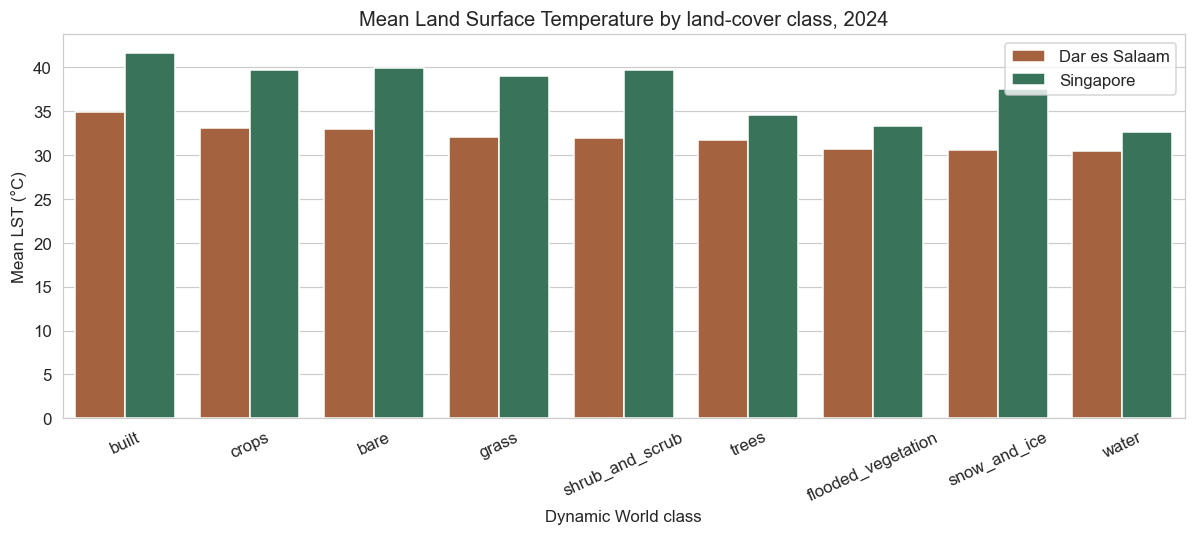

Saved: D:\uhi-dar-singapore\outputs\figures\04_lst_per_class.png


In [11]:
# Combined bar chart: the Siswanto-et-al-style figure
combined = pd.concat(class_stats.values(), ignore_index=True)

fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(data=combined, x='class', y='mean_LST', hue='city', ax=ax,
            palette={'Dar es Salaam': '#B65D2E', 'Singapore': '#2E7D5B'})
ax.set_xlabel('Dynamic World class')
ax.set_ylabel('Mean LST (°C)')
ax.set_title(f'Mean Land Surface Temperature by land-cover class, {YEAR}')
ax.tick_params(axis='x', rotation=25)
ax.legend(title='')
plt.tight_layout()
plt.savefig(out_dir / '04_lst_per_class.png', dpi=200, bbox_inches='tight')
plt.show()
print(f"Saved: {(out_dir / '04_lst_per_class.png').resolve()}")

## 9. Export results

In [12]:
out_tables = Path('../outputs/tables')
out_tables.mkdir(parents=True, exist_ok=True)

# Full sample dataset
df.to_csv(out_tables / '04_pixel_samples.csv', index=False)

# Correlation summary
corr_all = pd.concat(
    [t.assign(city=c) for c, t in corr_tables.items()],
    ignore_index=True,
)
corr_all.to_csv(out_tables / '04_correlations.csv', index=False)

# Per-class LST
combined.to_csv(out_tables / '04_lst_per_class.csv', index=False)

print("Saved:")
for p in out_tables.glob('04_*.csv'):
    print(f"  {p.resolve()}  ({p.stat().st_size/1024:.1f} KB)")

Saved:
  D:\uhi-dar-singapore\outputs\tables\04_correlations.csv  (0.7 KB)
  D:\uhi-dar-singapore\outputs\tables\04_lst_per_class.csv  (0.8 KB)
  D:\uhi-dar-singapore\outputs\tables\04_pixel_samples.csv  (1281.5 KB)
